In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# *Load Dataset*

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
file_path = '/content/drive/MyDrive/Colab Notebooks/MIS140_GlideWise360_data.csv'

df = pd.read_csv(file_path)

# *Inspect the Data*

In [58]:
print(df.shape)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

(8645, 19)
Number of rows: 8645
Number of columns: 19


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8645 entries, 0 to 8644
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RecordID                     8645 non-null   float64
 1   Shift_Manager_Code           8645 non-null   object 
 2   Date                         8645 non-null   object 
 3   Year                         8645 non-null   int64  
 4   Month                        8645 non-null   object 
 5   Hour                         8645 non-null   int64  
 6   Session_colour               8532 non-null   object 
 7   Weather_Outcast              8645 non-null   object 
 8   Temperature_Celsius          8645 non-null   float64
 9   Feeling_Temperature_Celsius  8645 non-null   int64  
 10  Humidity_Percent             8645 non-null   int64  
 11  Wind_Speed_kph               8645 non-null   int64  
 12  Season                       8645 non-null   object 
 13  Public_Holiday    

In [60]:
df.describe()

,RecordID,Year,Hour,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8645.00,8645.00,8645.00,8645.00,8645.00,8645.00,8645.00,8645.00,8558.00,8645.00
mean,432345632516.94,2011.00,11.57,14.99,14.95,64.35,12.83,115.19,47.81,143.79
std,249580792487.03,0.00,6.91,9.33,11.67,19.64,8.38,109.46,400.88,133.80
min,101012011.00,2011.00,0.00,-7.10,-16.00,0.00,0.00,0.00,-15.00,1.00
25%,216000000000.00,2011.00,6.00,7.00,5.00,49.00,7.00,26.00,3.00,31.00
50%,432000000000.00,2011.00,12.00,15.50,16.00,65.00,13.00,90.00,14.00,109.00
75%,648000000000.00,2011.00,18.00,23.00,25.00,81.00,19.00,168.00,39.00,211.00
max,865000000000.00,2011.00,23.00,85.00,50.00,135.00,150.00,567.00,9999.00,651.00


# *Clean the Data*

In [61]:
# Convert numeric columns (if stored as text)
df['Temperature_Celsius'] = pd.to_numeric(df['Temperature_Celsius'], errors='coerce')
df['Feeling_Temperature_Celsius'] = pd.to_numeric(df['Feeling_Temperature_Celsius'], errors='coerce')
df['Humidity_Percent'] = pd.to_numeric(df['Humidity_Percent'], errors='coerce')
df['Wind_Speed_kph'] = pd.to_numeric(df['Wind_Speed_kph'], errors='coerce')
df['Rental_Bikes_Total'] = pd.to_numeric(df['Rental_Bikes_Total'], errors='coerce')

# Convert date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [62]:
# Display rows where the 'Date' column contains NaT values = inconsistant
display(df[df['Date'].isna()])

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
277,27813012011.00,SM-10,NaT,2011,Jan,0,black,Clear,-1.40,-8,59,19,Winter,No,Thursday,yes,6,1.00,7
278,27913012011.00,SM-13,NaT,2011,Jan,1,green,Clear,-1.40,-8,50,19,Winter,No,Thursday,yes,2,0.00,2
279,28013012011.00,SM-11,NaT,2011,Jan,2,black,Clear,-1.40,-8,50,24,Winter,No,Thursday,yes,2,0.00,2
280,28113012011.00,SM-08,NaT,2011,Jan,3,yellow,Clear,-1.40,-8,50,22,Winter,No,Thursday,yes,3,0.00,3
281,28213012011.00,SM-10,NaT,2011,Jan,4,white,Clear,-1.40,-8,50,17,Winter,No,Thursday,yes,4,0.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,864000000000.00,SM-11,NaT,2011,Dec,19,purple,Clear,11.70,12,54,15,Winter,No,Saturday,No,73,19.00,92
8641,864000000000.00,SM-06,NaT,2011,Dec,20,white,Clear,11.70,12,54,15,Winter,No,Saturday,No,63,8.00,71
8642,864000000000.00,SM-10,NaT,2011,Dec,21,green,Clear,10.80,11,58,13,Winter,No,Saturday,No,50,2.00,52
8643,864000000000.00,SM-12,NaT,2011,Dec,22,green,Clear,9.90,10,62,9,Winter,No,Saturday,No,36,2.00,38


In [63]:
# Count missing values per column
df.isna().sum()

,0
RecordID,0
Shift_Manager_Code,0
Date,5216
Year,0
Month,0
Hour,0
Session_colour,113
Weather_Outcast,0
Temperature_Celsius,0
Feeling_Temperature_Celsius,0


In [64]:
# Check the total number of missing values per column sorted by descending order
df.isna().sum().sort_values(ascending=False)

,0
Date,5216
Session_colour,113
Casual_User_Count,87
Shift_Manager_Code,0
RecordID,0
Month,0
Year,0
Weather_Outcast,0
Temperature_Celsius,0
Feeling_Temperature_Celsius,0


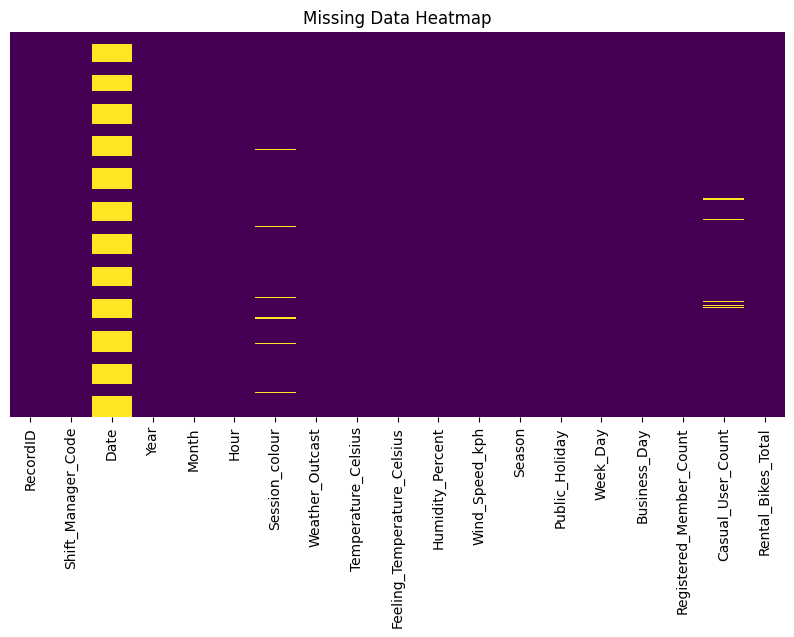

In [65]:
# Plot missing values as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

In [66]:
# Display the rows that contain missing values
df[df.isnull().any(axis=1)]

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
0,101012011.00,SM-10,2011-01-01,2011,Jan,0,red,Clear,3.30,3,81,0,Winter,Yes,Saturday,No,13,NaN,16
9,1001012011.00,SM-05,2011-01-01,2011,Jan,9,NaN,Clear,7.00,7,76,0,Winter,Yes,Saturday,No,6,8.00,14
54,5503012011.00,SM-05,2011-03-01,2011,Jan,9,NaN,Clear,-0.50,-7,43,26,Winter,No,Monday,yes,81,7.00,88
62,6303012011.00,SM-13,2011-03-01,2011,Jan,17,green,Clear,3.30,-1,30,15,Winter,No,Monday,yes,146,NaN,157
71,7204012011.00,SM-11,2011-04-01,2011,Jan,2,green,Clear,-1.40,-6,63,9,Winter,No,Tuesday,yes,1,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,864000000000.00,SM-11,NaT,2011,Dec,19,purple,Clear,11.70,12,54,15,Winter,No,Saturday,No,73,19.00,92
8641,864000000000.00,SM-06,NaT,2011,Dec,20,white,Clear,11.70,12,54,15,Winter,No,Saturday,No,63,8.00,71
8642,864000000000.00,SM-10,NaT,2011,Dec,21,green,Clear,10.80,11,58,13,Winter,No,Saturday,No,50,2.00,52
8643,864000000000.00,SM-12,NaT,2011,Dec,22,green,Clear,9.90,10,62,9,Winter,No,Saturday,No,36,2.00,38


In [67]:
df.dropna()

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
1,201012011.00,SM-11,2011-01-01,2011,Jan,1,black,Clear,2.30,2,80,0,Winter,Yes,Saturday,No,32,8.00,40
2,301012011.00,SM-02,2011-01-01,2011,Jan,2,blue,Clear,2.30,2,80,0,Winter,Yes,Saturday,No,27,5.00,32
3,401012011.00,SM-02,2011-01-01,2011,Jan,3,green,Clear,3.30,3,75,0,Winter,Yes,Saturday,No,10,3.00,13
4,501012011.00,SM-09,2011-01-01,2011,Jan,4,black,Clear,3.30,3,75,0,Winter,Yes,Saturday,No,1,0.00,1
5,601012011.00,SM-12,2011-01-01,2011,Jan,5,black,Mist and Cloudy,3.30,1,75,6,Winter,Yes,Saturday,No,1,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8187,819000000000.00,SM-02,2011-12-12,2011,Dec,19,red,Clear,5.20,4,61,6,Autumn,No,Monday,yes,232,9.00,241
8188,819000000000.00,SM-07,2011-12-12,2011,Dec,20,purple,Clear,6.10,5,56,6,Autumn,No,Monday,yes,157,8.00,165
8189,819000000000.00,SM-14,2011-12-12,2011,Dec,21,black,Clear,4.20,4,81,0,Autumn,No,Monday,yes,119,2.00,121
8190,819000000000.00,SM-13,2011-12-12,2011,Dec,22,purple,Clear,4.20,4,70,0,Autumn,No,Monday,yes,71,0.00,71


In [68]:
# Handle Session_colour missing values
# Option 1: Fill with 'Unknown'
df['Session_colour'] = df['Session_colour'].fillna('Unknown')

# Handle Casual_User_Count missing values
# Option 1: Fill with 0
df['Casual_User_Count'] = df['Casual_User_Count'].fillna(0)

# Handle Date missing values
# Option 1: Fill with 0
df['Date'] = df['Date'].fillna(0)

# Check again
df.isnull().sum()

,0
RecordID,0
Shift_Manager_Code,0
Date,0
Year,0
Month,0
Hour,0
Session_colour,0
Weather_Outcast,0
Temperature_Celsius,0
Feeling_Temperature_Celsius,0


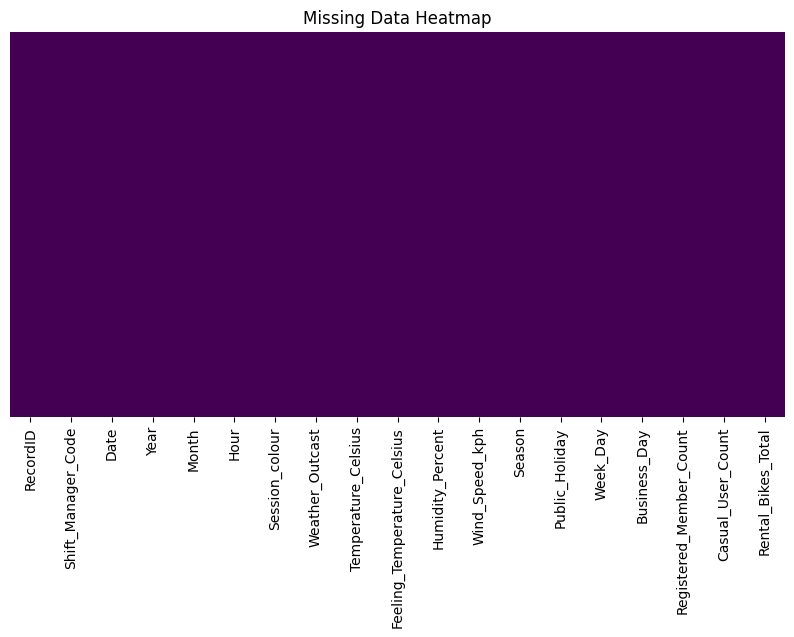

In [69]:
# Plot missing values as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

In [70]:
# Fix data types
df['RecordID'] = df['RecordID'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y", errors='coerce')
df['Casual_User_Count'] = df['Casual_User_Count'].fillna(0).astype(int)


# Handle missing values
df['Session_colour'] = df['Session_colour'].fillna('Unknown')

# Correctly convert 'Public_Holiday' and 'Business_Day' from 'Yes'/'No' strings to 1/0
# Use .str.lower() to handle potential case inconsistencies ('Yes'/'yes', 'No'/'no')
df['Public_Holiday'] = df['Public_Holiday'].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)
df['Business_Day'] = df['Business_Day'].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

# Convert other categorical columns to string type for later encoding if needed
# This list includes nominal columns and ordinal ones before OrdinalEncoder is applied.
other_categorical_cols = [
    'Shift_Manager_Code','Month','Session_colour','Weather_Outcast',
    'Season','Week_Day'
]
for col in other_categorical_cols:
    df[col] = df[col].astype('category').astype(str) # First to category, then to string for consistent type

# Remove unrealistic values
df = df[df['Rental_Bikes_Total'] >= 0]
df = df[(df['Humidity_Percent'] >= 0) & (df['Humidity_Percent'] <= 100)]
df = df[df['Wind_Speed_kph'] >= 0]

# Drop duplicates
df = df.drop_duplicates()

# Final check
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 8644 entries, 0 to 8644
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   RecordID                     8644 non-null   int64         
 1   Shift_Manager_Code           8644 non-null   object        
 2   Date                         3428 non-null   datetime64[ns]
 3   Year                         8644 non-null   int64         
 4   Month                        8644 non-null   object        
 5   Hour                         8644 non-null   int64         
 6   Session_colour               8644 non-null   object        
 7   Weather_Outcast              8644 non-null   object        
 8   Temperature_Celsius          8644 non-null   float64       
 9   Feeling_Temperature_Celsius  8644 non-null   int64         
 10  Humidity_Percent             8644 non-null   int64         
 11  Wind_Speed_kph               8644 non-null   int

,RecordID,Date,Year,Hour,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Public_Holiday,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8644.00,3428,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00
mean,432394549756.71,2011-06-21 18:36:07.561260288,2011.00,11.57,14.99,14.96,64.34,12.83,0.03,0.68,115.21,47.34,143.81
min,101012011.00,2011-01-01 00:00:00,2011.00,0.00,-7.10,-16.00,0.00,0.00,0.00,0.00,0.00,-15.00,1.00
25%,216000000000.00,2011-03-12 00:00:00,2011.00,6.00,7.00,5.00,49.00,7.00,0.00,0.00,26.00,3.00,31.00
50%,432000000000.00,2011-06-12 00:00:00,2011.00,12.00,15.50,16.00,65.00,13.00,0.00,1.00,90.00,13.00,109.00
75%,648250000000.00,2011-09-12 00:00:00,2011.00,18.00,23.00,25.00,81.00,19.00,0.00,1.00,168.00,38.00,211.00
max,865000000000.00,2011-12-12 00:00:00,2011.00,23.00,85.00,50.00,100.00,150.00,1.00,1.00,567.00,9999.00,651.00
std,249553781879.94,NaN,0.00,6.91,9.33,11.67,19.63,8.38,0.17,0.47,109.46,398.91,133.80


#*TRANSFORM DATA*


Normalise data

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Re-create df_encoded from the current df, as it was defined in a subsequent cell.
# This assumes that df has already undergone ordinal encoding as intended.
df_encoded = pd.get_dummies(
    df,
    columns=['Weather_Outcast','Shift_Manager_Code','Public_Holiday','Business_Day','Session_colour'],
    drop_first=True
)

# Select numerical columns
num_cols = ['Temperature_Celsius',
            'Feeling_Temperature_Celsius',
            'Humidity_Percent',
            'Wind_Speed_kph',
            'Rental_Bikes_Total']

# --- StandardScaler ---
scaler_standard = StandardScaler()
df_standard = df_encoded.copy()
df_standard[num_cols] = scaler_standard.fit_transform(df_standard[num_cols])
print("Standard Scaled:\n", df_standard[num_cols].head())

# --- MinMaxScaler ---
scaler_minmax = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[num_cols] = scaler_minmax.fit_transform(df_minmax[num_cols])
print("MinMax Scaled:\n", df_minmax[num_cols].head())

# --- RobustScaler ---
scaler_robust = RobustScaler()
df_robust = df_encoded.copy()
df_robust[num_cols] = scaler_robust.fit_transform(df_robust[num_cols])
print("Robust Scaled:\n", df_robust[num_cols].head())

Standard Scaled:
    Temperature_Celsius  Feeling_Temperature_Celsius  Humidity_Percent  \
0                -1.25                        -1.03              0.85   
1                -1.36                        -1.11              0.80   
2                -1.36                        -1.11              0.80   
3                -1.25                        -1.03              0.54   
4                -1.25                        -1.03              0.54   

   Wind_Speed_kph  Rental_Bikes_Total  
0           -1.53               -0.96  
1           -1.53               -0.78  
2           -1.53               -0.84  
3           -1.53               -0.98  
4           -1.53               -1.07  
MinMax Scaled:
    Temperature_Celsius  Feeling_Temperature_Celsius  Humidity_Percent  \
0                 0.11                         0.29              0.81   
1                 0.10                         0.27              0.80   
2                 0.10                         0.27              0.8

Encode categorical

In [72]:
# Define the list of categorical columns to encode
categorical_cols = ['Shift_Manager_Code', 'Month', 'Session_colour', 'Weather_Outcast']

# Encode categorical variables
for col in categorical_cols:
    # Ensure the column is of 'category' dtype before encoding
    df[col] = df[col].astype('category').cat.codes
df.head(10)

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
0,101012011,9,2011-01-01,2011,4,0,6,0,3.30,3,81,0,Winter,1,Saturday,0,13,0,16
1,201012011,10,2011-01-01,2011,4,1,1,0,2.30,2,80,0,Winter,1,Saturday,0,32,8,40
2,301012011,1,2011-01-01,2011,4,2,2,0,2.30,2,80,0,Winter,1,Saturday,0,27,5,32
3,401012011,1,2011-01-01,2011,4,3,3,0,3.30,3,75,0,Winter,1,Saturday,0,10,3,13
4,501012011,8,2011-01-01,2011,4,4,1,0,3.30,3,75,0,Winter,1,Saturday,0,1,0,1
5,601012011,11,2011-01-01,2011,4,5,1,3,3.30,1,75,6,Winter,1,Saturday,0,1,0,1
6,701012011,10,2011-01-01,2011,4,6,8,0,2.30,2,80,0,Winter,1,Saturday,0,0,2,2
7,801012011,7,2011-01-01,2011,4,7,1,0,1.40,1,86,0,Winter,1,Saturday,0,2,1,3
8,901012011,1,2011-01-01,2011,4,8,2,0,3.30,3,75,0,Winter,1,Saturday,0,7,1,8
9,1001012011,4,2011-01-01,2011,4,9,0,0,7.00,7,76,0,Winter,1,Saturday,0,6,8,14


Ordinal encoding

In [73]:
from sklearn.preprocessing import OrdinalEncoder

# Define ordered categories
catagories_orders = [
    ['Winter','Spring','Summer','Autumn'],
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
]
encoder = OrdinalEncoder(categories=catagories_orders)

# Apply encoding
df[['Season','Week_Day']] = encoder.fit_transform(df[['Season','Week_Day']])

print(df[['Season','Week_Day']].head())

# Season: Winter=0, Spring=1, Summer=2, Autumn=3
# Week_Day: Monday=0, Tuesday=1, … Sunday=6

   Season  Week_Day
0    0.00      5.00
1    0.00      5.00
2    0.00      5.00
3    0.00      5.00
4    0.00      5.00


One-hot encoding

In [74]:
df_encoded = pd.get_dummies(
    df,
    columns=['Weather_Outcast','Shift_Manager_Code','Public_Holiday','Business_Day','Session_colour'],
    drop_first=True
)
print(df_encoded.head())

    RecordID       Date  Year  Month  Hour  Temperature_Celsius  \
0  101012011 2011-01-01  2011      4     0                 3.30   
1  201012011 2011-01-01  2011      4     1                 2.30   
2  301012011 2011-01-01  2011      4     2                 2.30   
3  401012011 2011-01-01  2011      4     3                 3.30   
4  501012011 2011-01-01  2011      4     4                 3.30   

   Feeling_Temperature_Celsius  Humidity_Percent  Wind_Speed_kph  Season  ...  \
0                            3                81               0    0.00  ...   
1                            2                80               0    0.00  ...   
2                            2                80               0    0.00  ...   
3                            3                75               0    0.00  ...   
4                            3                75               0    0.00  ...   

   Public_Holiday_1  Business_Day_1  Session_colour_1  Session_colour_2  \
0              True           False

In [75]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 8644 entries, 0 to 8644
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   RecordID                     8644 non-null   int64         
 1   Shift_Manager_Code           8644 non-null   int8          
 2   Date                         3428 non-null   datetime64[ns]
 3   Year                         8644 non-null   int64         
 4   Month                        8644 non-null   int8          
 5   Hour                         8644 non-null   int64         
 6   Session_colour               8644 non-null   int8          
 7   Weather_Outcast              8644 non-null   int8          
 8   Temperature_Celsius          8644 non-null   float64       
 9   Feeling_Temperature_Celsius  8644 non-null   int64         
 10  Humidity_Percent             8644 non-null   int64         
 11  Wind_Speed_kph               8644 non-null   int

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8644.00,8644.00,3428,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00,8644.00
mean,432394549756.71,6.50,2011-06-21 18:36:07.561260288,2011.00,5.53,11.57,4.47,0.95,14.99,14.96,64.34,12.83,1.51,0.03,3.01,0.68,115.21,47.34,143.81
min,101012011.00,0.00,2011-01-01 00:00:00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-15.00,1.00
25%,216000000000.00,3.00,2011-03-12 00:00:00,2011.00,2.00,6.00,2.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,432000000000.00,7.00,2011-06-12 00:00:00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,13.00,109.00
75%,648250000000.00,10.00,2011-09-12 00:00:00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,38.00,211.00
max,865000000000.00,13.00,2011-12-12 00:00:00,2011.00,11.00,23.00,8.00,3.00,85.00,50.00,100.00,150.00,3.00,1.00,6.00,1.00,567.00,9999.00,651.00
std,249553781879.94,4.04,NaN,0.00,3.46,6.91,2.32,1.33,9.33,11.67,19.63,8.38,1.11,0.17,2.00,0.47,109.46,398.91,133.80


Rows where Registered + Casual did not equal Rental_Bikes_Total were removed. This ensures logical consistency in the dataset and avoids introducing assumptions about which variable was incorrect.

In [76]:
# Fix unrealistic values

# Casual users: replace negatives with 0
df.loc[df['Casual_User_Count'] < 0, 'Casual_User_Count'] = 0

# Cap extreme casual counts (e.g., >1000) to a reasonable max
df.loc[df['Casual_User_Count'] > 1000, 'Casual_User_Count'] = 1000

# Remove unrealistic temperature values
df = df[df['Temperature_Celsius'] <= 50]

# Cap extreme wind speeds
df.loc[df['Wind_Speed_kph'] > 100, 'Wind_Speed_kph'] = 100

df.describe()

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8643.00,8643.00,3428,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00,8643.00
mean,432346811072.19,6.50,2011-06-21 18:36:07.561260288,2011.00,5.53,11.57,4.47,0.95,14.98,14.96,64.34,12.82,1.51,0.03,3.01,0.68,115.22,30.82,143.82
min,101012011.00,0.00,2011-01-01 00:00:00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,216000000000.00,3.00,2011-03-12 00:00:00,2011.00,2.00,6.00,2.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,432000000000.00,7.00,2011-06-12 00:00:00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,13.00,109.00
75%,648000000000.00,10.00,2011-09-12 00:00:00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,38.00,211.00
max,865000000000.00,13.00,2011-12-12 00:00:00,2011.00,11.00,23.00,8.00,3.00,37.10,50.00,100.00,100.00,3.00,1.00,6.00,1.00,567.00,1000.00,651.00
std,249528744995.59,4.04,NaN,0.00,3.46,6.91,2.32,1.33,9.30,11.67,19.63,8.31,1.11,0.17,2.00,0.47,109.46,62.45,133.80


In [77]:
# Remove rows where Registered + Casual ≠ Rental_Bikes_Total
df = df[df['Registered_Member_Count'] + df['Casual_User_Count'] == df['Rental_Bikes_Total']]

df.describe()

,RecordID,Shift_Manager_Code,Date,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8524.00,8524.00,3380,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00
mean,432799051835.62,6.51,2011-06-21 20:49:08.165680640,2011.00,5.53,11.58,4.48,0.95,14.97,14.94,64.31,12.83,1.52,0.03,3.01,0.68,115.19,28.67,143.86
min,201012011.00,0.00,2011-01-01 00:00:00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,216000000000.00,3.00,2011-03-27 00:00:00,2011.00,2.00,6.00,3.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,433000000000.00,7.00,2011-06-21 12:00:00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,14.00,109.00
75%,649000000000.00,10.00,2011-09-12 00:00:00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,39.00,211.00
max,865000000000.00,13.00,2011-12-12 00:00:00,2011.00,11.00,23.00,8.00,3.00,37.10,50.00,100.00,100.00,3.00,1.00,6.00,1.00,567.00,272.00,651.00
std,249788133215.27,4.04,NaN,0.00,3.46,6.91,2.32,1.33,9.30,11.67,19.63,8.32,1.11,0.17,2.00,0.47,109.35,38.92,133.78


“Initial preprocessing capped extreme casual counts at 1000. However, consistency checks revealed that these extreme values were part of rows where Registered + Casual did not equal Rental_Bikes_Total. After removing inconsistent rows, the maximum casual user count reduced to 272. This adjustment ensures logical integrity and reflects realistic demand levels.”

In [78]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"New DataFrame shape: {df.shape}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
New DataFrame shape: (8524, 19)


In [79]:
# Save the cleaned dataset as a CSV file
df.to_csv("cleaned_data.csv", index=False)

df = pd.read_csv("cleaned_data.csv")

# *UNIVARIATE ANALYSIS*

In [80]:
# df.describe() no scientific number
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,RecordID,Shift_Manager_Code,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00
mean,432799051835.62,6.51,2011.00,5.53,11.58,4.48,0.95,14.97,14.94,64.31,12.83,1.52,0.03,3.01,0.68,115.19,28.67,143.86
std,249788133215.27,4.04,0.00,3.46,6.91,2.32,1.33,9.30,11.67,19.63,8.32,1.11,0.17,2.00,0.47,109.35,38.92,133.78
min,201012011.00,0.00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,216000000000.00,3.00,2011.00,2.00,6.00,3.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,433000000000.00,7.00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,14.00,109.00
75%,649000000000.00,10.00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,39.00,211.00
max,865000000000.00,13.00,2011.00,11.00,23.00,8.00,3.00,37.10,50.00,100.00,100.00,3.00,1.00,6.00,1.00,567.00,272.00,651.00


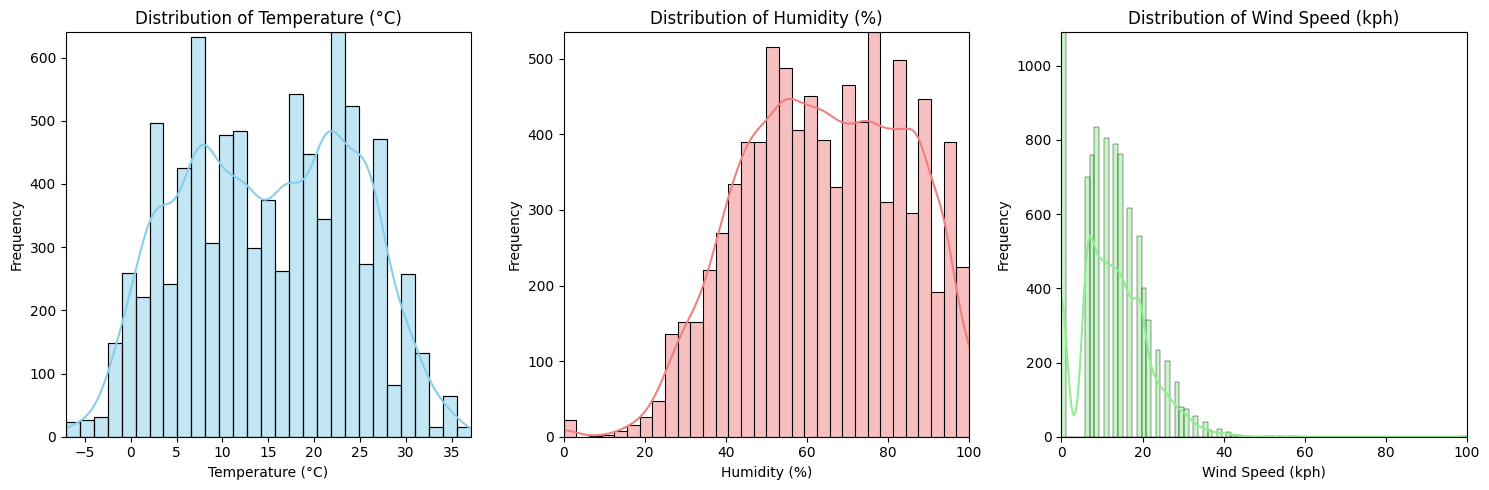

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for the histograms
plt.figure(figsize=(15, 5))

# Histogram for Temperature_Celsius
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Temperature_Celsius'], kde=True, color='skyblue')
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

# Histogram for Humidity_Percent
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Humidity_Percent'], kde=True, color='lightcoral')
plt.title('Distribution of Humidity (%)')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

# Histogram for Wind_Speed_kph
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Wind_Speed_kph'], kde=True, color='lightgreen')
plt.title('Distribution of Wind Speed (kph)')
plt.xlabel('Wind Speed (kph)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

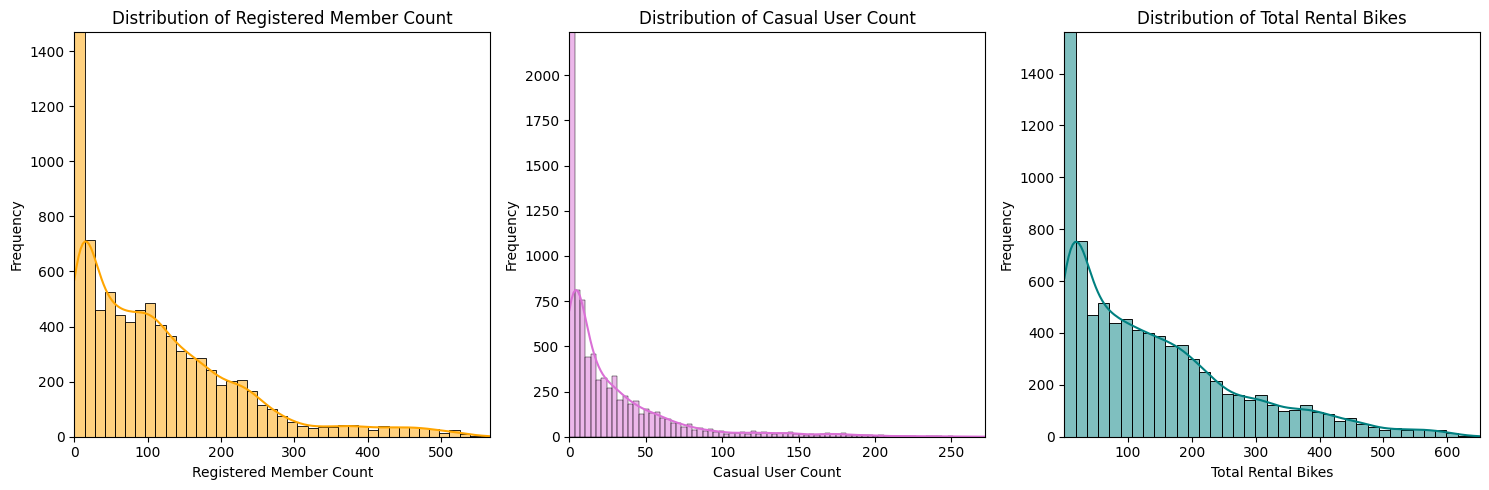

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for the histograms
plt.figure(figsize=(15, 5))

# Histogram for Registered_Member_Count
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Registered_Member_Count'], kde=True, color='orange')
plt.title('Distribution of Registered Member Count')
plt.xlabel('Registered Member Count')
plt.ylabel('Frequency')

# Histogram for Casual_User_Count
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Casual_User_Count'], kde=True, color='orchid')
plt.title('Distribution of Casual User Count')
plt.xlabel('Casual User Count')
plt.ylabel('Frequency')

# Histogram for Rental_Bikes_Total
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.margins(x=0)
plt.margins(y=0)
sns.histplot(df['Rental_Bikes_Total'], kde=True, color='teal')
plt.title('Distribution of Total Rental Bikes')
plt.xlabel('Total Rental Bikes')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

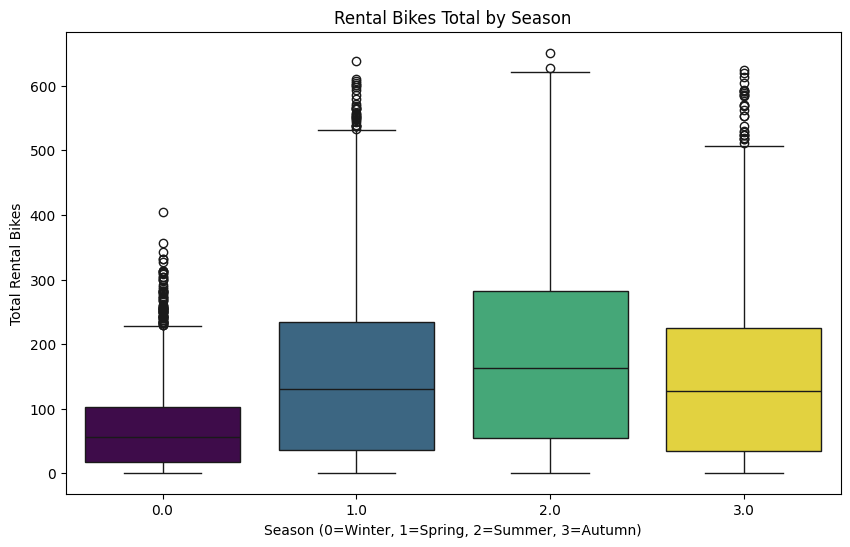

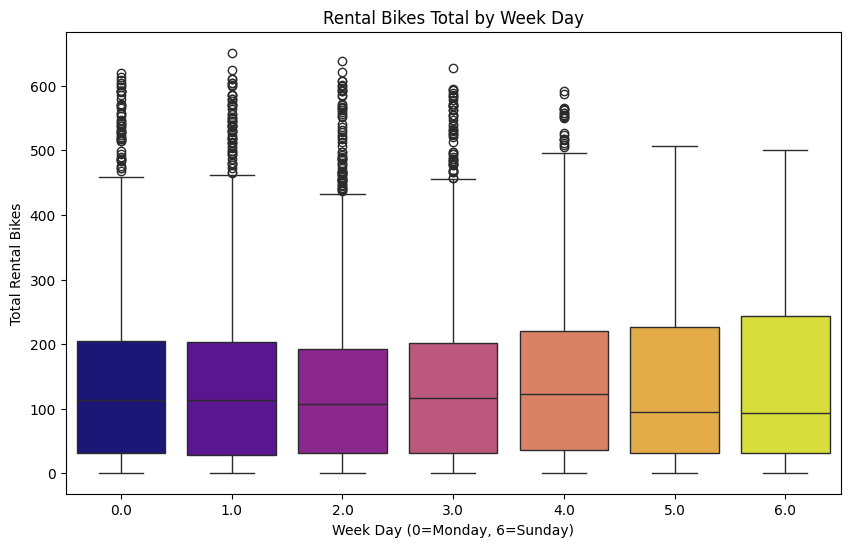

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Rental_Bikes_Total', data=df, palette='viridis', hue='Season', legend=False)
plt.title('Rental Bikes Total by Season')
plt.xlabel('Season (0=Winter, 1=Spring, 2=Summer, 3=Autumn)')
plt.ylabel('Total Rental Bikes')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Week_Day', y='Rental_Bikes_Total', data=df, palette='plasma', hue='Week_Day', legend=False)
plt.title('Rental Bikes Total by Week Day')
plt.xlabel('Week Day (0=Monday, 6=Sunday)')
plt.ylabel('Total Rental Bikes')
plt.show()

# *OUTLIERS*

In [84]:
# Identify numerical columns for outlier detection
numeric_cols = [
    'Registered_Member_Count',
    'Casual_User_Count',
    'Rental_Bikes_Total',
    'Temperature_Celsius',
    'Humidity_Percent',
    'Wind_Speed_kph'
]

# Dictionary to store outlier counts for each column
outlier_counts = {}

print("Outlier Detection using IQR Method:")
print("----------------------------------")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Store and print the count of outliers
    outlier_counts[col] = len(outliers)
    print(f"Column: {col}\n  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}\n  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}\n  Number of Outliers: {len(outliers)}\n")

Outlier Detection using IQR Method:
----------------------------------
Column: Registered_Member_Count
  Q1: 26.00, Q3: 168.00, IQR: 142.00
  Lower Bound: -187.00, Upper Bound: 381.00
  Number of Outliers: 338

Column: Casual_User_Count
  Q1: 3.00, Q3: 39.00, IQR: 36.00
  Lower Bound: -51.00, Upper Bound: 93.00
  Number of Outliers: 577

Column: Rental_Bikes_Total
  Q1: 31.00, Q3: 211.00, IQR: 180.00
  Lower Bound: -239.00, Upper Bound: 481.00
  Number of Outliers: 209

Column: Temperature_Celsius
  Q1: 7.00, Q3: 23.00, IQR: 16.00
  Lower Bound: -17.00, Upper Bound: 47.00
  Number of Outliers: 0

Column: Humidity_Percent
  Q1: 49.00, Q3: 81.00, IQR: 32.00
  Lower Bound: 1.00, Upper Bound: 129.00
  Number of Outliers: 22

Column: Wind_Speed_kph
  Q1: 7.00, Q3: 19.00, IQR: 12.00
  Lower Bound: -11.00, Upper Bound: 37.00
  Number of Outliers: 52



handles outliers

In [85]:
# Columns for which to cap outliers
capping_cols = [
    'Registered_Member_Count',
    'Casual_User_Count',
    'Rental_Bikes_Total',
    'Temperature_Celsius',
    'Humidity_Percent',
    'Wind_Speed_kph'
]

for col in capping_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ensure lower bounds make sense for count-based or percentage features
    if col in ['Registered_Member_Count', 'Casual_User_Count', 'Rental_Bikes_Total', 'Wind_Speed_kph']:
        lower_bound = max(0, lower_bound)
    if col == 'Humidity_Percent':
        lower_bound = max(0, lower_bound)
        upper_bound = min(100, upper_bound) # Humidity cannot exceed 100%

    # Apply capping
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been capped for the following columns:")
for col in capping_cols:
    print(f"- {col}")

# Verify by checking descriptive statistics again or re-running outlier detection
df.describe()

Outliers have been capped for the following columns:
- Registered_Member_Count
- Casual_User_Count
- Rental_Bikes_Total
- Temperature_Celsius
- Humidity_Percent
- Wind_Speed_kph


,RecordID,Shift_Manager_Code,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00
mean,432799051835.62,6.51,2011.00,5.53,11.58,4.48,0.95,14.97,14.94,64.32,12.79,1.52,0.03,3.01,0.68,112.42,25.19,142.33
std,249788133215.27,4.04,0.00,3.46,6.91,2.32,1.33,9.30,11.67,19.62,8.15,1.11,0.17,2.00,0.47,101.03,28.02,129.34
min,201012011.00,0.00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,216000000000.00,3.00,2011.00,2.00,6.00,3.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,433000000000.00,7.00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,14.00,109.00
75%,649000000000.00,10.00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,39.00,211.00
max,865000000000.00,13.00,2011.00,11.00,23.00,8.00,3.00,37.10,50.00,100.00,37.00,3.00,1.00,6.00,1.00,381.00,93.00,481.00


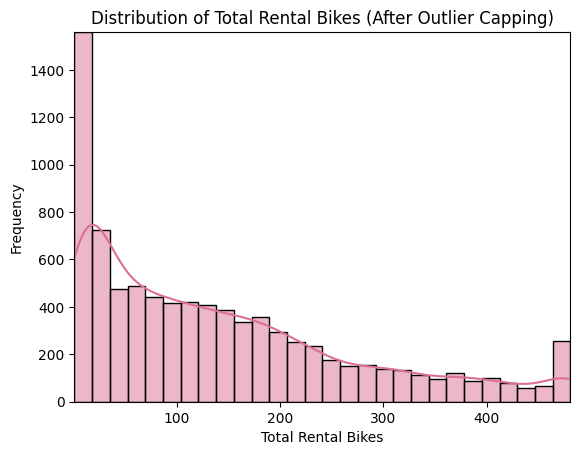

In [86]:
sns.histplot(df['Rental_Bikes_Total'], kde=True, color='palevioletred')
plt.margins(x=0)
plt.margins(y=0)
plt.title('Distribution of Total Rental Bikes (After Outlier Capping)')
plt.xlabel('Total Rental Bikes')
plt.ylabel('Frequency')
plt.show()

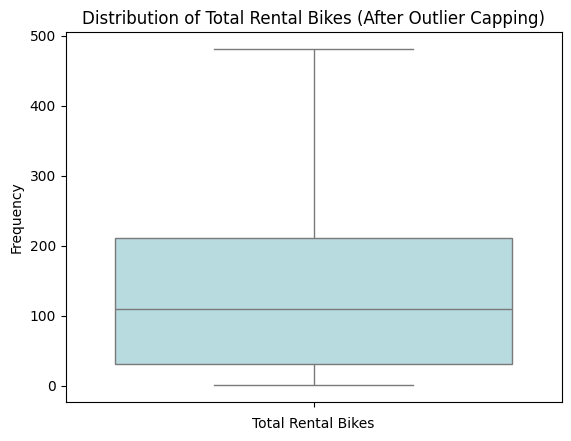

In [87]:
sns.boxplot(df['Rental_Bikes_Total'], color='powderblue')
plt.title('Distribution of Total Rental Bikes (After Outlier Capping)')
plt.xlabel('Total Rental Bikes')
plt.ylabel('Frequency')
plt.show()

# **Lazy EDA for univariate analysis**

In [88]:
df.describe()

,RecordID,Shift_Manager_Code,Year,Month,Hour,Session_colour,Weather_Outcast,Temperature_Celsius,Feeling_Temperature_Celsius,Humidity_Percent,Wind_Speed_kph,Season,Public_Holiday,Week_Day,Business_Day,Registered_Member_Count,Casual_User_Count,Rental_Bikes_Total
count,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00,8524.00
mean,432799051835.62,6.51,2011.00,5.53,11.58,4.48,0.95,14.97,14.94,64.32,12.79,1.52,0.03,3.01,0.68,112.42,25.19,142.33
std,249788133215.27,4.04,0.00,3.46,6.91,2.32,1.33,9.30,11.67,19.62,8.15,1.11,0.17,2.00,0.47,101.03,28.02,129.34
min,201012011.00,0.00,2011.00,0.00,0.00,0.00,0.00,-7.10,-16.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,216000000000.00,3.00,2011.00,2.00,6.00,3.00,0.00,7.00,5.00,49.00,7.00,1.00,0.00,1.00,0.00,26.00,3.00,31.00
50%,433000000000.00,7.00,2011.00,6.00,12.00,5.00,0.00,15.50,16.00,65.00,13.00,2.00,0.00,3.00,1.00,90.00,14.00,109.00
75%,649000000000.00,10.00,2011.00,9.00,18.00,7.00,3.00,23.00,25.00,81.00,19.00,2.00,0.00,5.00,1.00,168.00,39.00,211.00
max,865000000000.00,13.00,2011.00,11.00,23.00,8.00,3.00,37.10,50.00,100.00,37.00,3.00,1.00,6.00,1.00,381.00,93.00,481.00


# *BIVARIATE ANALYSIS*

numerical vs numerical

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8524 entries, 0 to 8523
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RecordID                     8524 non-null   int64  
 1   Shift_Manager_Code           8524 non-null   int64  
 2   Date                         3380 non-null   object 
 3   Year                         8524 non-null   int64  
 4   Month                        8524 non-null   int64  
 5   Hour                         8524 non-null   int64  
 6   Session_colour               8524 non-null   int64  
 7   Weather_Outcast              8524 non-null   int64  
 8   Temperature_Celsius          8524 non-null   float64
 9   Feeling_Temperature_Celsius  8524 non-null   int64  
 10  Humidity_Percent             8524 non-null   int64  
 11  Wind_Speed_kph               8524 non-null   int64  
 12  Season                       8524 non-null   float64
 13  Public_Holiday    

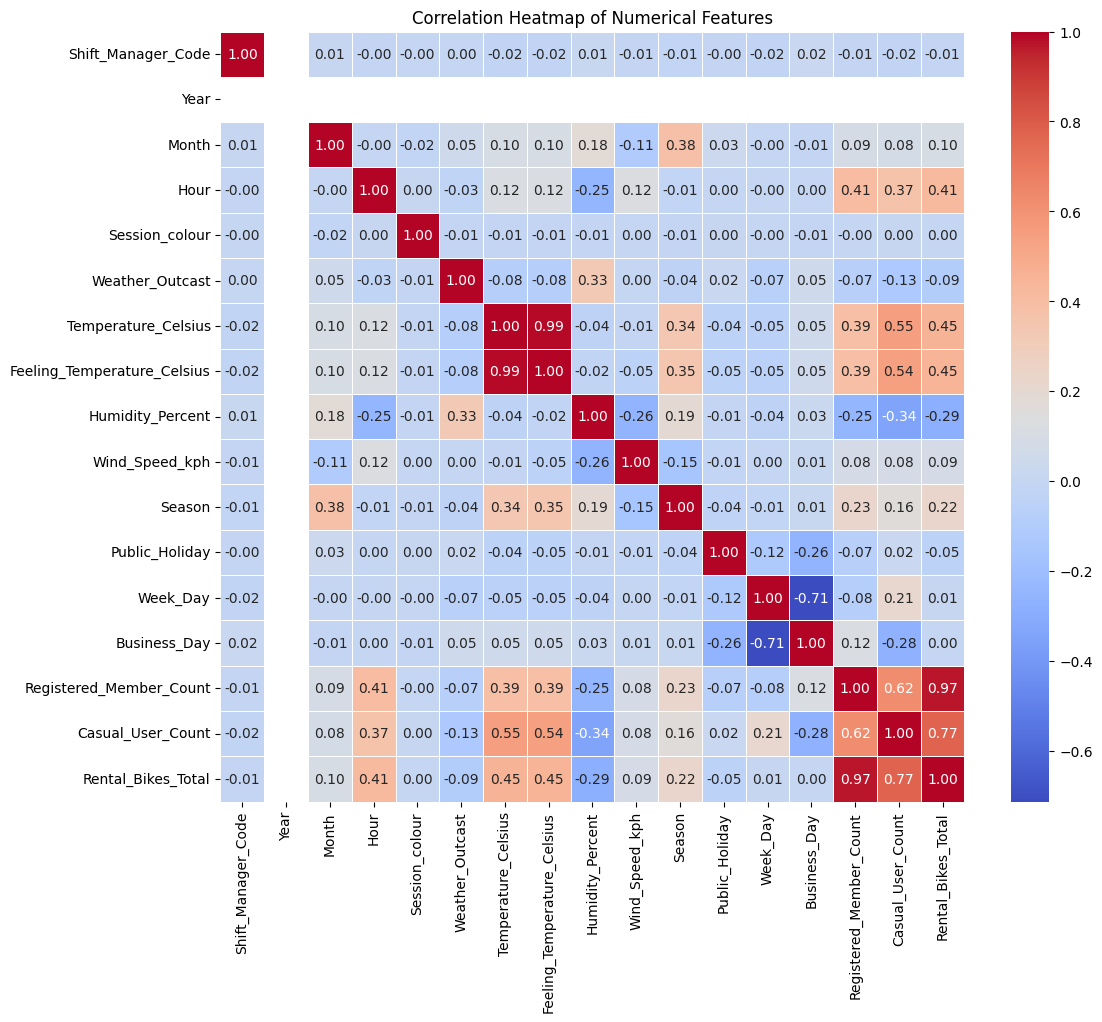

In [90]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'RecordID' as it's an identifier and not a true numerical feature for correlation
if 'RecordID' in numerical_cols:
    numerical_cols.remove('RecordID')

# Exclude 'Date' if it's still present as a numerical representation or datetime
if 'Date' in numerical_cols:
    numerical_cols.remove('Date')

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**WEATHER**

In [91]:
correlation_matrix = df[['Temperature_Celsius','Humidity_Percent','Wind_Speed_kph','Rental_Bikes_Total']].corr()
r = correlation_matrix.loc[['Temperature_Celsius','Humidity_Percent','Wind_Speed_kph'], 'Rental_Bikes_Total']
print("Correlation coefficients (r) with Rental_Bikes_Total:\n", r)

Correlation coefficients (r) with Rental_Bikes_Total:
 Temperature_Celsius    0.45
Humidity_Percent      -0.29
Wind_Speed_kph         0.09
Name: Rental_Bikes_Total, dtype: float64


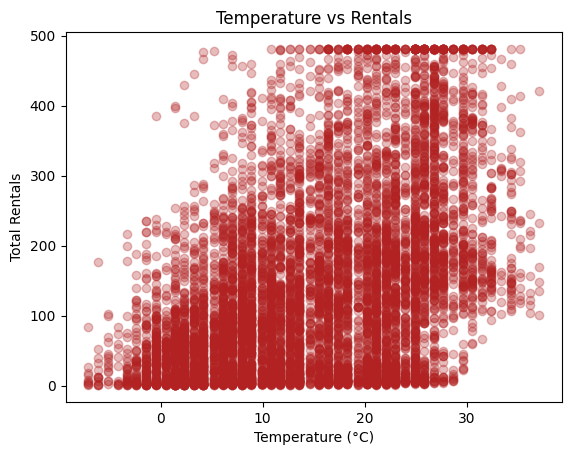

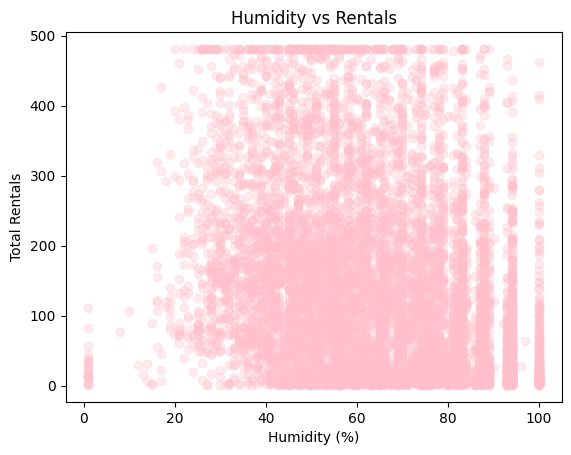

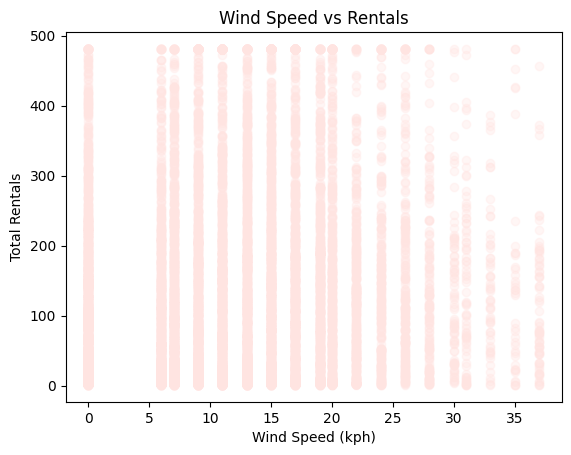

In [92]:
# Temperature vs Rentals
plt.scatter(df['Temperature_Celsius'], df['Rental_Bikes_Total'], alpha=0.3, color='firebrick')
plt.title("Temperature vs Rentals")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Rentals")
plt.show()

# Humidity vs Rentals
plt.scatter(df['Humidity_Percent'], df['Rental_Bikes_Total'], alpha=0.3, color='pink')
plt.title("Humidity vs Rentals")
plt.xlabel("Humidity (%)")
plt.ylabel("Total Rentals")
plt.show()

# Wind Speed vs Rentals
plt.scatter(df['Wind_Speed_kph'], df['Rental_Bikes_Total'], alpha=0.3, color='mistyrose')
plt.title("Wind Speed vs Rentals")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("Total Rentals")
plt.show()

In [93]:
# Display summary statistics for categorical variables
print("Numerical Variable Summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 39)

Numerical Variable Summary:

Column: Shift_Manager_Code
Shift_Manager_Code
4     635
12    629
3     624
11    623
1     622
5     618
10    617
8     617
0     611
9     608
7     600
13    593
2     570
6     557
Name: count, dtype: int64
---------------------------------------

Column: Month
Month
2     735
10    734
8     731
5     730
1     722
7     721
9     712
0     709
6     707
11    707
4     679
3     637
Name: count, dtype: int64
---------------------------------------

Column: Session_colour
Session_colour
7    1095
3    1086
5    1076
6    1062
4    1040
8    1039
1    1021
2     995
0     110
Name: count, dtype: int64
---------------------------------------

Column: Weather_Outcast
Weather_Outcast
0    5574
3    2182
2     767
1       1
Name: count, dtype: int64
---------------------------------------


catagorical vs numerical

**SEASON**

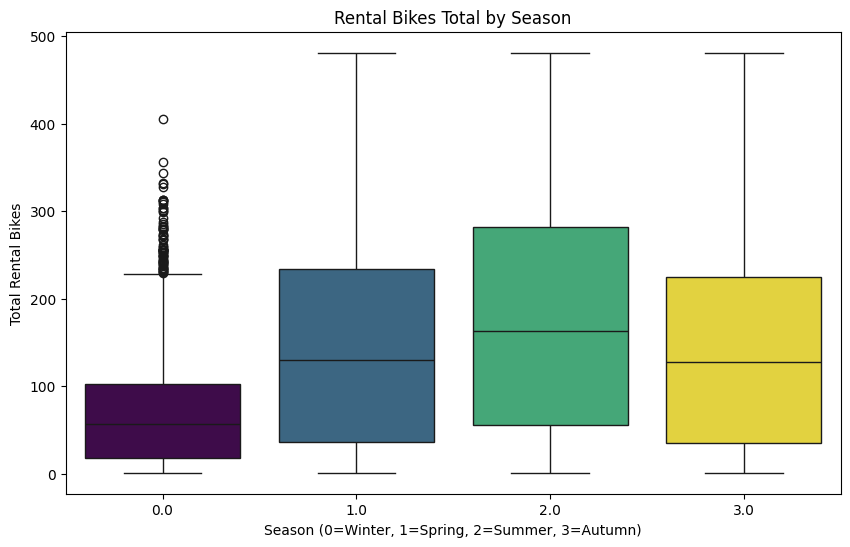

In [94]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Rental_Bikes_Total', data=df, palette='viridis', hue='Season', legend=False)
plt.title('Rental Bikes Total by Season')
plt.xlabel('Season (0=Winter, 1=Spring, 2=Summer, 3=Autumn)')
plt.ylabel('Total Rental Bikes')
plt.show()

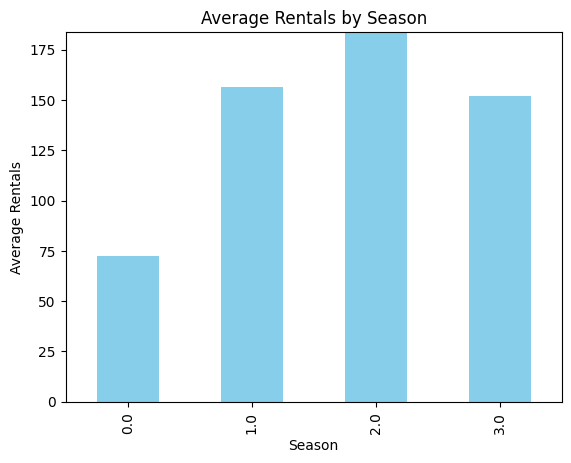

Season
0.00    72.58
1.00   156.50
2.00   183.77
3.00   151.76
Name: Rental_Bikes_Total, dtype: float64


In [95]:
season_usage = df.groupby('Season')['Rental_Bikes_Total'].mean()

season_usage.plot(kind='bar', color='skyblue')
plt.margins(x=0)
plt.margins(y=0)
plt.title("Average Rentals by Season")
plt.ylabel("Average Rentals")
plt.show()

df.describe()
print(season_usage)


# Season: Winter=0, Spring=1, Summer=2, Autumn=3


**WEEKDAY**

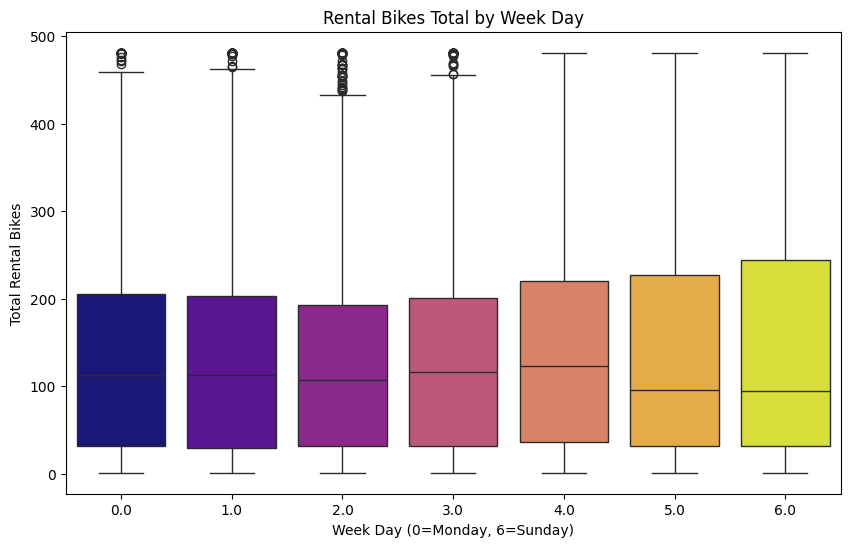

In [96]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Week_Day', y='Rental_Bikes_Total', data=df, palette='plasma', hue='Week_Day', legend=False)
plt.title('Rental Bikes Total by Week Day')
plt.xlabel('Week Day (0=Monday, 6=Sunday)')
plt.ylabel('Total Rental Bikes')
plt.show()

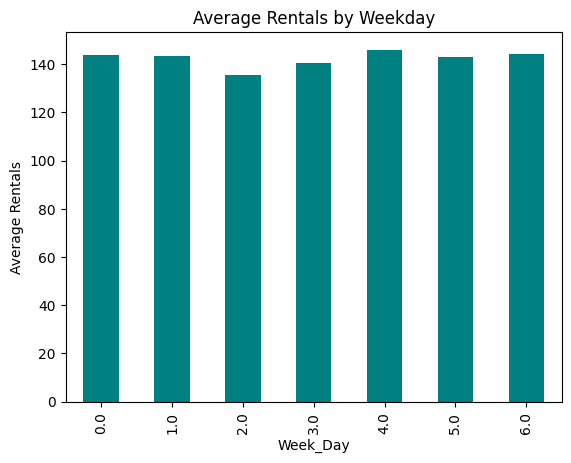

Week_Day
0.00   143.77
1.00   143.43
2.00   135.30
3.00   140.59
4.00   146.04
5.00   142.90
6.00   144.19
Name: Rental_Bikes_Total, dtype: float64


In [97]:
weekday_usage = df.groupby('Week_Day')['Rental_Bikes_Total'].mean()

weekday_usage.plot(kind='bar', color='teal')
plt.title("Average Rentals by Weekday")
plt.ylabel("Average Rentals")
plt.show()

df.describe()
print(weekday_usage)

# Week_Day: Monday=0, Tuesday=1, … Sunday=6

**HOLIDAYS**

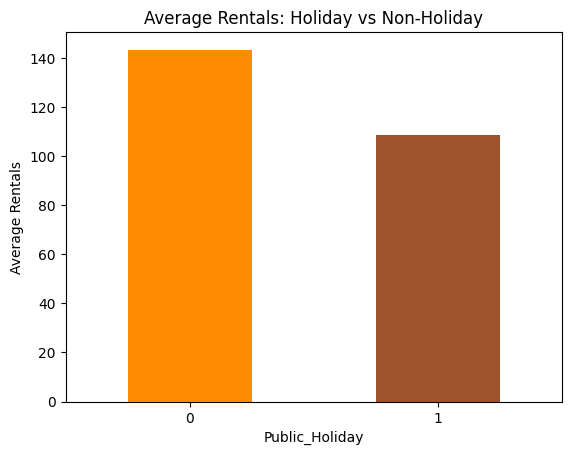

Public_Holiday
0   143.38
1   108.70
Name: Rental_Bikes_Total, dtype: float64


In [98]:
holiday_usage = df.groupby('Public_Holiday')['Rental_Bikes_Total'].mean()
holiday_usage.plot(kind='bar', color=['darkorange','sienna'])
plt.title("Average Rentals: Holiday vs Non-Holiday")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()
print(holiday_usage)

# 1 = holidays

**USAGE**

In [99]:
# Compare average rentals
ave_registered = df['Registered_Member_Count'].mean()
ave_casual = df['Casual_User_Count'].mean()

print("Average Registered Rentals:", ave_registered)
print("Average Casual Rentals:", ave_casual)

Average Registered Rentals: 112.42268887846082
Average Casual Rentals: 25.19251525105584


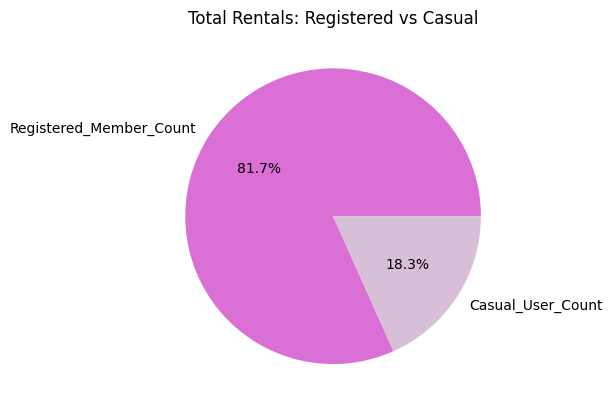

Axes(0.22375,0.11;0.5775x0.77)


In [100]:
# Plot totals
usage_insights = df[['Registered_Member_Count','Casual_User_Count']].sum().plot(kind='pie', autopct='%1.1f%%', colors=('orchid','thistle'))
plt.title("Total Rentals: Registered vs Casual")
plt.show()

print(usage_insights)

**HOURLY**

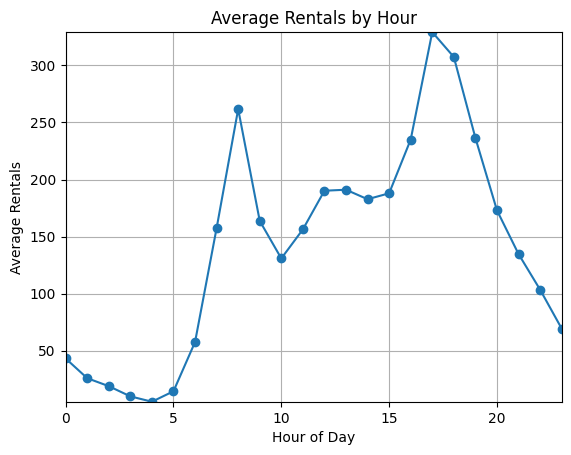

In [101]:
hourly_usage = df.groupby('Hour')['Rental_Bikes_Total'].mean()

hourly_usage.plot(kind='line', marker='o')
plt.margins(x=0)
plt.margins(y=0)
plt.title("Average Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()



**BUSINESS DAY**

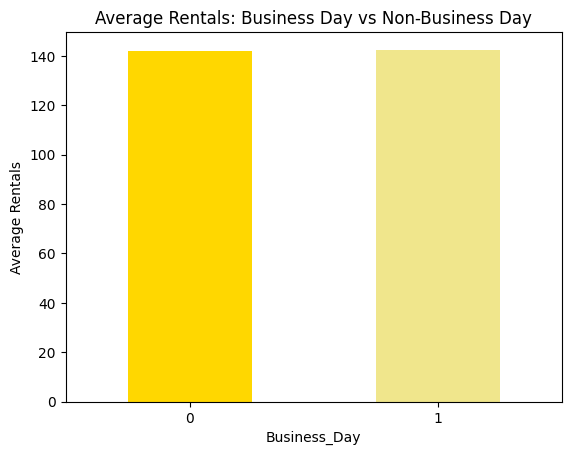

Business_Day
0   141.88
1   142.54
Name: Rental_Bikes_Total, dtype: float64


In [102]:
business_usage = df.groupby('Business_Day')['Rental_Bikes_Total'].mean()
business_usage.plot(kind='bar', color=['gold','khaki'])
plt.title("Average Rentals: Business Day vs Non-Business Day")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.show()

print(business_usage)
# 1 = business day

categorical vs categorical

In [103]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Public_Holiday'], df['Business_Day'])
chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square:", chi2, "p-value:", p)

Chi-square: 573.8627446214623 p-value: 8.110933557892798e-127


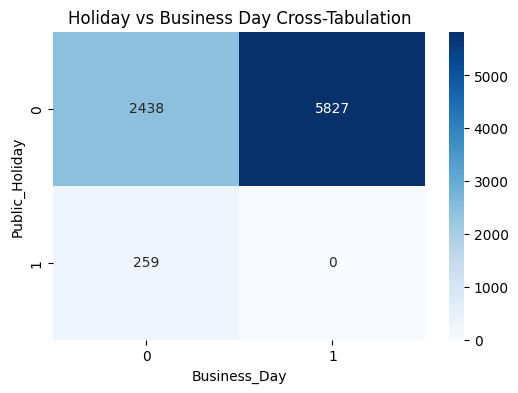

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(df['Public_Holiday'], df['Business_Day'])

plt.figure(figsize=(6,4))
sns.heatmap(table, annot=True, cmap="Blues", fmt="d")
plt.title("Holiday vs Business Day Cross-Tabulation")
plt.show()

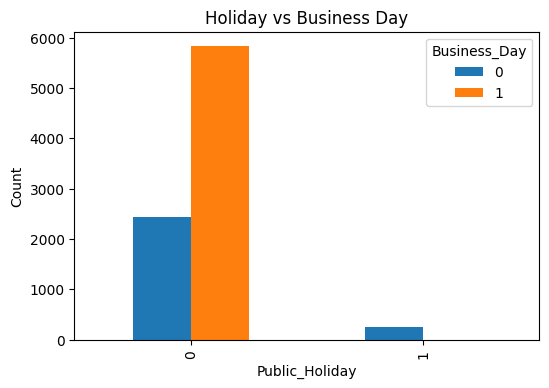

In [105]:
table = pd.crosstab(df['Public_Holiday'], df['Business_Day'])

table.plot(kind="bar", stacked=False, figsize=(6,4))
plt.title("Holiday vs Business Day")
plt.ylabel("Count")
plt.show()

# ***MULTIVARIATE ANALYSIS***

In [106]:
import statsmodels.api as sm

# Define predictors and target
X = df[['Temperature_Celsius', 'Humidity_Percent', 'Business_Day','Registered_Member_Count', 'Casual_User_Count']]
y = df['Rental_Bikes_Total']

# Add constant for intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Rental_Bikes_Total   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 1.388e+05
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:01:31   Log-Likelihood:                -34736.
No. Observations:                8524   AIC:                         6.948e+04
Df Residuals:                    8518   BIC:                         6.953e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

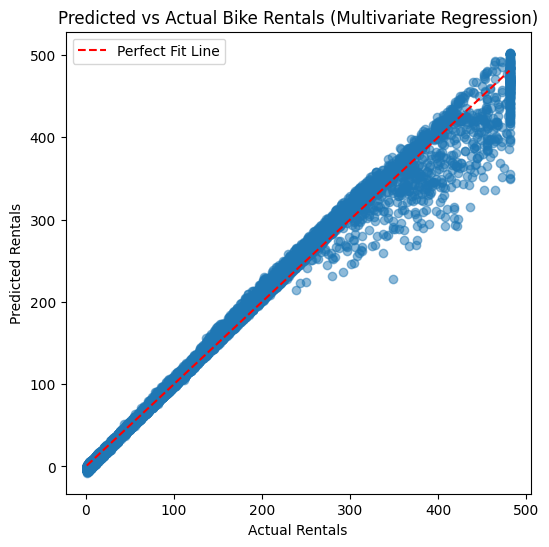

In [107]:

plt.figure(figsize=(6,6))
plt.scatter(y, model.fittedvalues, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit Line")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Predicted vs Actual Bike Rentals (Multivariate Regression)")
plt.legend()
plt.show()